# Survival Analysis Lung Adenocarcinoma

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [16]:
# Load data
df = pd.read_excel("Luad_mskcc_2023.xlsx")
df.head()

,Study ID,Patient ID,Sample ID,Adjuvant,Adjuvant Chemotherapy,Adjuvant Immunotherapy,Adjuvant Targeted,Adjuvant Therapy,Adjuvant XRT,Adrenal Met Status (Months),...,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Somatic Status,TGF-Beta Pathway,TMB (nonsynonymous),TP53 Pathway,WNT Pathway
0,luad_mskcc_2023_met_organotropism,P-0000149,P-0000149-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tumor,1,883.0,Metastasis,Female,Matched,No,9.982398,No,No
1,luad_mskcc_2023_met_organotropism,P-0000163,P-0000163-T02-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tumor,1,439.0,Metastasis,Female,Matched,No,3.327466,Yes,No
2,luad_mskcc_2023_met_organotropism,P-0000208,P-0000208-T01-WES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,Primary,NaN,Matched,NaN,2.933333,NaN,NaN
3,luad_mskcc_2023_met_organotropism,P-0000208,P-0000208-T02-WES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,Metastasis,NaN,Matched,NaN,1.600000,NaN,NaN
4,luad_mskcc_2023_met_organotropism,P-0000219,P-0000219-T01-IM3,Yes,Yes,No,No,Yes,Yes,NaN,...,Tumor,1,1033.0,Primary,Female,Matched,Yes,4.436621,No,No


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 94 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Study ID                                      2653 non-null   object 
 1   Patient ID                                    2653 non-null   object 
 2   Sample ID                                     2653 non-null   object 
 3   Adjuvant                                      641 non-null    object 
 4   Adjuvant Chemotherapy                         880 non-null    object 
 5   Adjuvant Immunotherapy                        880 non-null    object 
 6   Adjuvant Targeted                             880 non-null    object 
 7   Adjuvant Therapy                              603 non-null    object 
 8   Adjuvant XRT                                  880 non-null    object 
 9   Adrenal Met Status (Months)                   38 non-null     f

## Preprocessing

In [18]:
df = pd.read_excel('Luad_mskcc_2023.xlsx')

columns_needed = [
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Age at Surgery/Biopsy",
    "Sex",
    "Race Category",
    "Tobacco History",
    "TMB (nonsynonymous)",
    "Fraction Genome Altered",
    "Gene Panel",
    "Predominant Histologic Subtype"
]

df = df[columns_needed].copy()

rename_map = {
    "TMB (nonsynonymous)": "TMB_nonsynonymous",
    "Race Category": "Race_Category",
    "Predominant Histologic Subtype": "Predominant_Histologic_Subtype",
    "Gene Panel": "Gene_Panel",
    "Tobacco History": "Tobacco_History",
    "Fraction Genome Altered": "Fraction_Genome_Altered",
    "Age at Surgery/Biopsy": "Age_at_Surgery_Biopsy"
}
df.rename(columns=rename_map, inplace=True)

# Hapus duplikat
print(f"Jumlah duplikat sebelum: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Jumlah duplikat setelah: {df.duplicated().sum()}")

# Hapus baris dengan missing pada target survival
df = df.dropna(subset=['Overall Survival (Months)', 'Overall Survival Status']).copy()

# Hapus baris dengan missing pada semua variabel analisis (complete-case)
df = df.dropna().copy()

# Encode survival status
df['event'] = df['Overall Survival Status'].map({'0:LIVING': 0, '1:DECEASED': 1})
df['time'] = df['Overall Survival (Months)']

print(f"\nData akhir: {df.shape[0]} baris, {df.shape[1]} kolom")

Jumlah duplikat sebelum: 13
Jumlah duplikat setelah: 0

Data akhir: 638 baris, 12 kolom


In [19]:
# Simpan variabel numerik dan kategorikal
numerical_vars = ['Age_at_Surgery_Biopsy', 'TMB_nonsynonymous', 'Fraction_Genome_Altered']
categorical_vars = ['Sex', 'Race_Category', 'Tobacco_History', 'Gene_Panel', 'Predominant_Histologic_Subtype']

# One-hot encoding dengan drop_first untuk hindari multikolinearitas
df_encoded = pd.get_dummies(
    df,
    columns=categorical_vars,
    drop_first=True,
    prefix_sep='_'
)

# Simpan daftar kolom kategorikal dummy untuk referensi
dummy_cols = [col for col in df_encoded.columns if any(cat in col for cat in categorical_vars)]

print(f"\nJumlah kolom setelah encoding: {df_encoded.shape[1]}")
print("Kolom dummy (contoh 5):", dummy_cols[:5])


Jumlah kolom setelah encoding: 20
Kolom dummy (contoh 5): ['Sex_Male', 'Race_Category_Black', 'Race_Category_Other', 'Race_Category_Unknown', 'Race_Category_White']


## Kaplan-Meier


=== Kaplan-Meier & Log-rank: Sex ===


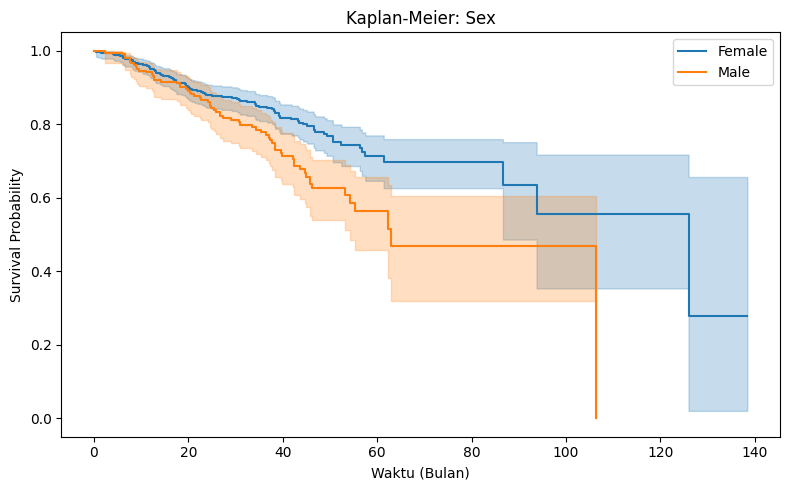

Log-rank p-value (2 grup): 0.0540

=== Kaplan-Meier & Log-rank: Race_Category ===


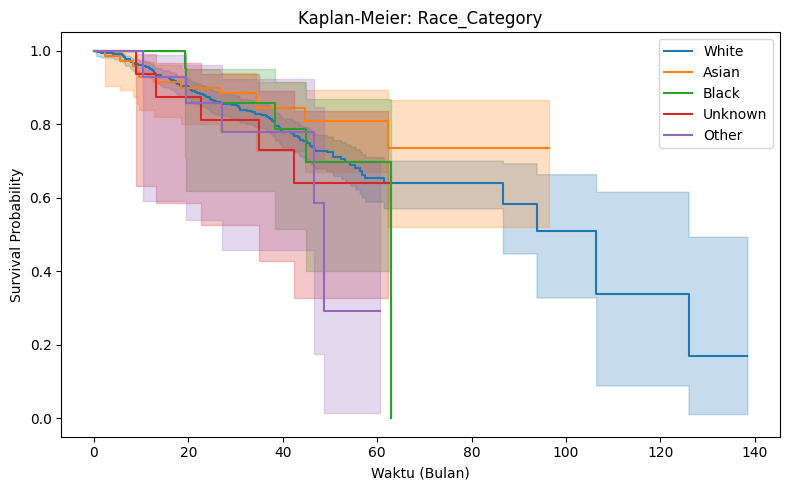

Multivariate Log-rank p-value (>2 grup): 0.4970

=== Kaplan-Meier & Log-rank: Tobacco_History ===


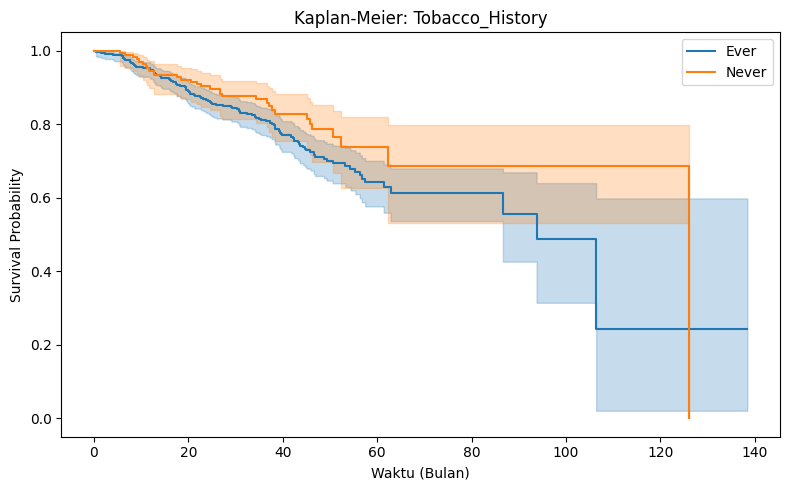

Log-rank p-value (2 grup): 0.6424

=== Kaplan-Meier & Log-rank: Gene_Panel ===


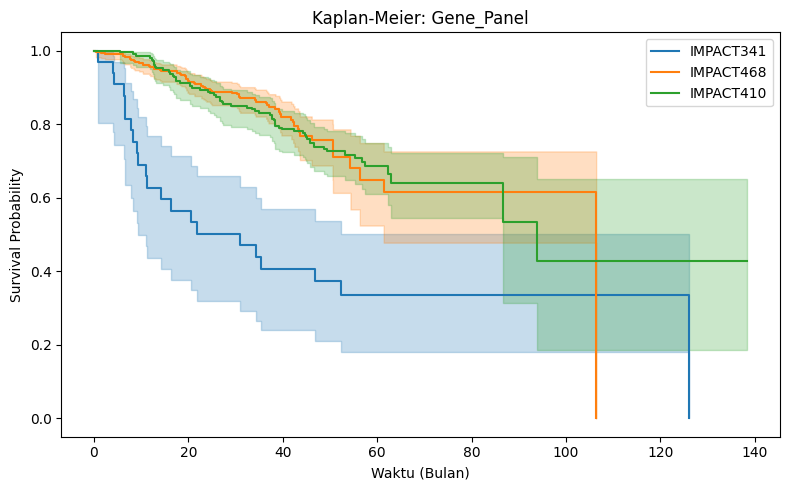

Multivariate Log-rank p-value (>2 grup): 0.0000

=== Kaplan-Meier & Log-rank: Predominant_Histologic_Subtype ===


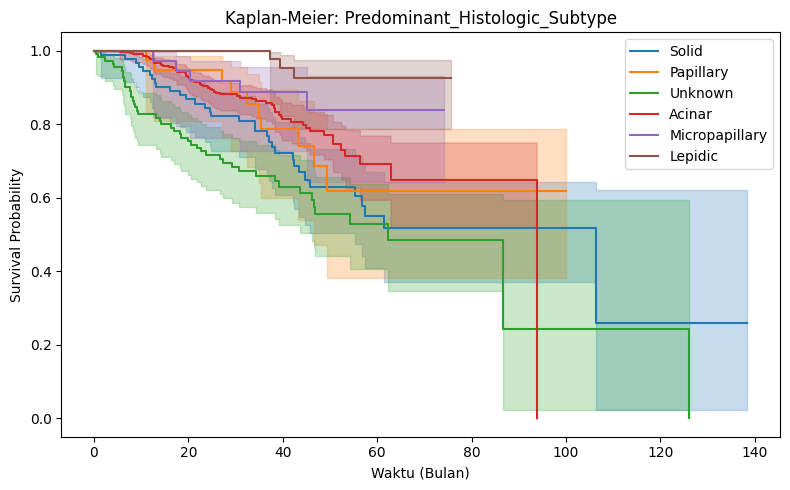

Multivariate Log-rank p-value (>2 grup): 0.0000


In [20]:
for var in categorical_vars:
    print(f"\n=== Kaplan-Meier & Log-rank: {var} ===")
    if df[var].nunique() < 2:
        print("Hanya 1 kategori → lewati.")
        continue

    # Plot KM
    plt.figure(figsize=(8, 5))
    kmf = KaplanMeierFitter()
    groups = df[var].dropna().unique()

    for group in groups:
        mask = df[var] == group
        if mask.sum() < 5:
            continue
        kmf.fit(df.loc[mask, 'time'], df.loc[mask, 'event'], label=str(group))
        kmf.plot()
    plt.title(f'Kaplan-Meier: {var}')
    plt.xlabel('Waktu (Bulan)')
    plt.ylabel('Survival Probability')
    plt.tight_layout()
    plt.show()

    # Uji Log-rank
    durations = df['time']
    events = df['event']
    group_labels = df[var]

    if df[var].nunique() == 2:
        unique_vals = df[var].unique()
        mask1 = df[var] == unique_vals[0]
        mask2 = df[var] == unique_vals[1]
        test = logrank_test(
            df.loc[mask1, 'time'], df.loc[mask2, 'time'],
            event_A=df.loc[mask1, 'event'], event_B=df.loc[mask2, 'event']
        )
        print(f"Log-rank p-value (2 grup): {test.p_value:.4f}")
    else:
        test = multivariate_logrank_test(durations, group_labels, events)
        print(f"Multivariate Log-rank p-value (>2 grup): {test.p_value:.4f}")


## Regresi Cox

In [21]:
# Tentukan kolom untuk model Cox (tanpa kolom asli kategorikal)
cox_cols = numerical_vars + dummy_cols + ['time', 'event']
cph_df = df_encoded[cox_cols].copy()

# Fit Cox model
cph = CoxPHFitter()
cph.fit(cph_df, duration_col='time', event_col='event')

print("\n=== Hasil Regresi Cox ===")
cph.print_summary()


=== Hasil Regresi Cox ===


<lifelines.CoxPHFitter: fitted with 638 total observations, 483 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 638
number of events observed = 155
   partial log-likelihood = -873.02
         time fit was run = 2025-12-19 13:32:04 UTC

---
                                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                      
Age_at_Surgery_Biopsy                          0.01      1.01      0.01           -0.01            0.03                0.99                1.03
TMB_nonsynonymous                              0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Fraction_Genome_Altered                        1.29      3.63      0.58            0.15            2.43                1.16               11.31
Sex_Male                                       0.47      1.60      0.17            0.14            0.80                1.15                2.23
Race_Category_Black                            0.49      1.63      0.51           -0.51            1.49                0.60                4.46
Race_Category_Other                            0.92      2.50      0.55           -0.16            1.99                0.85                7.32
Race_Category_Unknown                          0.51      1.66      0.55           -0.56            1.58                0.57                4.85
Race_Category_White                            0.17      1.18      0.32           -0.46            0.80                0.63                2.22
Tobacco_History_Never                         -0.50      0.61      0.23           -0.95           -0.04                0.39                0.96
Gene_Panel_IMPACT410                          -1.08      0.34      0.27           -1.62           -0.54                0.20                0.58
Gene_Panel_IMPACT468                          -1.21      0.30      0.27           -1.74           -0.69                0.18                0.50
Predominant_Histologic_Subtype_Lepidic        -1.51      0.22      0.60           -2.68           -0.34                0.07                0.71
Predominant_Histologic_Subtype_Micropapillary -0.54      0.58      0.47           -1.46            0.38                0.23                1.46
Predominant_Histologic_Subtype_Papillary       0.04      1.04      0.35           -0.64            0.72                0.53                2.05
Predominant_Histologic_Subtype_Solid           0.40      1.50      0.23           -0.05            0.86                0.95                2.36
Predominant_Histologic_Subtype_Unknown         0.68      1.98      0.21            0.28            1.09                1.32                2.97

                                               cmp to     z      p  -log2(p)
covariate                                                                   
Age_at_Surgery_Biopsy                            0.00  1.35   0.18      2.50
TMB_nonsynonymous                                0.00  0.25   0.80      0.32
Fraction_Genome_Altered                          0.00  2.22   0.03      5.25
Sex_Male                                         0.00  2.79   0.01      7.55
Race_Category_Black                              0.00  0.96   0.34      1.57
Race_Category_Other                              0.00  1.67   0.09      3.40
Race_Category_Unknown                            0.00  0.93   0.35      1.51
Race_Category_White                              0.00  0.52   0.60      0.73
Tobacco_History_Never                            0.00 -2.14   0.03      4.94
Gene_Panel_IMPACT410                             0.00 -3.94 <0.005     13.61
Gene_Panel_IMPACT468                             0.00 -4.51 <0.005     17.22
Predominant_Histologic_Subtype_Lepidic           

## Uji Asumsi PH

In [22]:
print("\n=== Uji Asumsi Proportional Hazards ===")
try:
    cph.check_assumptions(cph_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print("Peringatan saat uji PH:", e)

# Ekstrak variabel yang melanggar (dari output string)
# Karena lifelines tidak memberikan API langsung, kita tangkap dari string
import io
from contextlib import redirect_stdout

f = io.StringIO()
with redirect_stdout(f):
    cph.check_assumptions(cph_df, p_value_threshold=0.05, show_plots=False)
output = f.getvalue()

violations = []
for line in output.split('\n'):
    if "failed the non-proportional test" in line:
        # Ekstrak nama variabel dari notasi [T....] → ambil bagian sebelum [T
        if '[' in line:
            var_name = line.split('[')[0].split()[-1]
            if var_name not in violations:
                violations.append(var_name)

print(f"\nVariabel asli yang melanggar PH: {violations}")



=== Uji Asumsi Proportional Hazards ===
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 638 total observations, 483 right-censored observations>
         test_name = proportional_hazard_test

---
                                                    test_statistic      p  -log2(p)
Age_at_Surgery_Biopsy                         km              2.14   0.14      2.80
                                              rank            3.65   0.06      4.16
Fraction_Genome_Altered                       km              0.11   0.73      0.44
                                              rank            0.19   0.67      0.59
Gene_Panel_IMPACT410                          km              5.51   0.02      5.72
                                              rank            6.93   0.01      6.89
Gene_Panel_IMPACT468                          km              7.27   0.01      7.16
                                              rank            8.41 <0.005      8.07
Predominant_Histologic_Subtype_Lepidic        km              0.30   0.58      0.78
                                              rank            0.89   0.35      1.53
Predominant_Histologic_Subtype_Micropapillary km              0.40   0.53      0.92
                                              rank            0.43   0.51      0.97
Predominant_Histologic_Subtype_Papillary      km              0.08   0.77      0.37
                                              rank            0.46   0.50      1.01
Predominant_Histologic_Subtype_Solid          km              0.15   0.70      0.51
                                              rank            0.10   0.75      0.42
Predominant_Histologic_Subtype_Unknown        km              3.75   0.05      4.24
                                              rank            6.76   0.01      6.74
Race_Category_Black                           km              1.71   0.19      2.38
                                              rank            2.71   0.10      3.33
Race_Category_Other                           km              2.01   0.16      2.67
                                              rank            3.35   0.07      3.89
Race_Category_Unknown                         km              0.03   0.86      0.21
                                              rank            0.18   0.67      0.57
Race_Category_White                           km              0.76   0.38      1.38
                                              rank            1.72   0.19      2.40
Sex_Male                                      km              1.55   0.21      2.23
                                              rank            1.94   0.16      2.61
TMB_nonsynonymous                             km              0.01   0.93      0.10
                                              rank            0.00   0.98      0.04
Tobacco_History_Never                         km              0.01   0.93      0.10
                                              rank            0.33   0.57      0.81

<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 638 total observations, 483 right-censored observations>
         test_name = proportional_hazard_test

---
                                                    test_statistic      p  -log2(p)
Age_at_Surgery_Biopsy                         km              2.14   0.14      2.80
                                              rank            3.65   0.06      4.16
Fraction_Genome_Altered                       km              0.11   0.73      0.44
                                              rank            0.19   0.67      0.59
Gene_Panel_IMPACT410                          km              5.51   0.02      5.72
                                              rank            6.93   0.01      6.89
Gene_Panel_IMPACT468                          km              7.27   0.01      7.16
                                              rank            8.41 <0.005      8.07
Predominant_Histologic_Subtype_Lepidic        km              0.30   0.58      0.78
                                              rank            0.89   0.35      1.53
Predominant_Histologic_Subtype_Micropapillary km              0.40   0.53      0.92
                                              rank            0.43   0.51      0.97
Predominant_Histologic_Subtype_Papillary      km              0.08   0.77      0.37
                                              rank            0.46   0.50      1.01
Predominant_Histologic_Subtype_Solid          km              0.15   0.70      0.51
                                              rank            0.10   0.75      0.42
Predominant_Histologic_Subtype_Unknown        km              3.75   0.05      4.24
                                              rank            6.76   0.01      6.74
Race_Category_Black                           km              1.71   0.19      2.38
                                              rank            2.71   0.10      3.33
Race_Category_Other                           km              2.01   0.16      2.67
                                              rank            3.35   0.07      3.89
Race_Category_Unknown                         km              0.03   0.86      0.21
                                              rank            0.18   0.67      0.57
Race_Category_White                           km              0.76   0.38      1.38
                                              rank            1.72   0.19      2.40
Sex_Male                                      km              1.55   0.21      2.23
                                              rank            1.94   0.16      2.61
TMB_nonsynonymous                             km              0.01   0.93      0.10
                                              rank            0.00   0.98      0.04
Tobacco_History_Never                         km              0.01   0.93      0.10
                                              rank            0.33   0.57      0.81



1. Variable 'Gene_Panel_IMPACT410' failed the non-proportional test: p-value is 0.0085.

   Advice: with so few unique values (only 2), you can include `strata=['Gene_Panel_IMPACT410',
...]` in the call in `.fit`. See documentation in link [E] below.

2. Variable 'Gene_Panel_IMPACT468' failed the non-proportional test: p-value is 0.0037.

   Advice: with so few unique values (only 2), you can include `strata=['Gene_Panel_IMPACT468',
...]` in the call in `.fit`. See documentation in link [E] below.

3. Variable 'Predominant_Histologic_Subtype_Unknown' failed the non-proportional test: p-value is 0.0093.

   Advice: with so few unique values (only 2), you can include
`strata=['Predominant_Histologic_Subtype_Unknown', ...]` in the call in `.fit`. See documentation in
link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assump

## Regresi Cox Stratifikasi

In [23]:
if violations:
    # Pilih variabel utama untuk stratifikasi (prioritaskan Gene_Panel jika ada)
    if 'Gene_Panel' in violations:
        strat_var = 'Gene_Panel'
    else:
        strat_var = violations[0]
    
    print(f"\nMelakukan stratifikasi berdasarkan: {strat_var}")
    
    # Siapkan data tanpa encoding untuk variabel yang akan di-stratifikasi
    # Tapi encoding tetap untuk variabel lain
    df_for_strat = df.copy()
    
    # Encode semua kategorikal KECUALI yang di-stratifikasi
    cats_to_encode = [v for v in categorical_vars if v != strat_var]
    df_strat_encoded = pd.get_dummies(
        df_for_strat,
        columns=cats_to_encode,
        drop_first=True,
        prefix_sep='_'
    )
    
    # Pastikan kolom 'time' dan 'event' ada
    cph_strat_df = df_strat_encoded.copy()

    # Fit model dengan stratifikasi
    cph_strat = CoxPHFitter()
    cph_strat.fit(
        cph_strat_df,
        duration_col='time',
        event_col='event',
        strata=[strat_var]
    )
    
    print(f"\n=== Hasil Regresi Cox dengan Stratifikasi pada '{strat_var}' ===")
    cph_strat.print_summary()
    
    # Simpan model akhir
    final_model = cph_strat
else:
    print("\nTidak ada pelanggaran asumsi PH → model awal valid.")
    final_model = cph


Tidak ada pelanggaran asumsi PH → model awal valid.
